<a href="https://colab.research.google.com/github/5ahar-K/Project/blob/main/optimisation%20AR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AR(1) CORRELATION PARAMETERS
  data_rate   = 1.0 Gbps
  t_slot      = 1.00 ns
  Tc_theta    = 0.0 ms  ->  rho_theta = 0.904837
  Tc_h1       = 2.0 ms  ->  rho_h1    = 1.000000

Building Malaga CDF... done.


--- sigma_I/wa = 1.0 ---
    sigma_I = 2.00 mm
    delta   = 2.000 mm
    fc_eff  = 52.000 mm
  sigma_I/wa=1.0  Pt= -25.0 dBm  RMSE=694.4244 um  P_int=0.6163
  sigma_I/wa=1.0  Pt= -21.1 dBm  RMSE=688.7640 um  P_int=0.3087
  sigma_I/wa=1.0  Pt= -17.1 dBm  RMSE=679.5103 um  P_int=0.1198
  sigma_I/wa=1.0  Pt= -13.2 dBm  RMSE=669.8192 um  P_int=0.0400
  sigma_I/wa=1.0  Pt=  -9.2 dBm  RMSE=666.0610 um  P_int=0.0137
  sigma_I/wa=1.0  Pt=  -5.3 dBm  RMSE=661.5268 um  P_int=0.0049
  sigma_I/wa=1.0  Pt=  -1.3 dBm  RMSE=659.6957 um  P_int=0.0014
  sigma_I/wa=1.0  Pt=   2.6 dBm  RMSE=662.3408 um  P_int=0.0005
  sigma_I/wa=1.0  Pt=   6.6 dBm  RMSE=660.3527 um  P_int=0.0001
  sigma_I/wa=1.0  Pt=  10.5 dBm  RMSE=661.5524 um  P_int=0.0001
  sigma_I/wa=1.0  Pt=  14.5 dBm  RMSE=660.4685 um  P_int=0

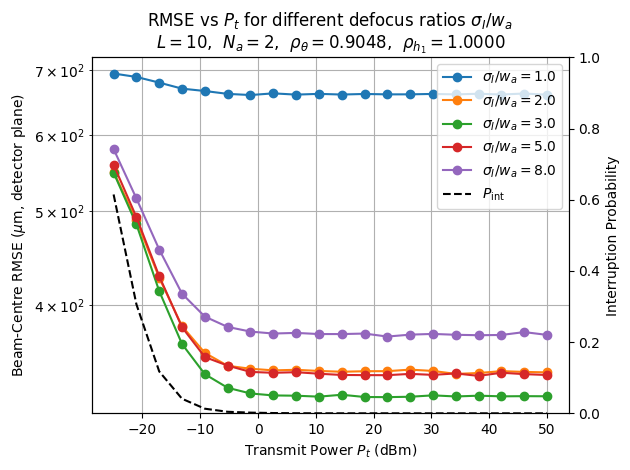

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math

def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))

def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa, sigma_I_ratio):
    """
    sigma_I_ratio = sigma_I / wa  (e.g. 0.5, 1, 2, 3)
    fc_eff = fc + delta where delta = sigma_I * fc / ra
    """
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)
    sigma_I = sigma_I_ratio * wa
    delta   = sigma_I * fc / ra
    fc_eff  = fc + delta
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I,
            "delta": delta, "fc_eff": fc_eff}

def ar1_coefficient(Tc, data_rate):
    return float(np.exp(-1.0 / (data_rate * Tc)))

def ar1_noise_std(sigma, rho):
    return sigma * np.sqrt(1.0 - rho**2)

def generate_ar1_block(B, L, sigma, rho, rng):
    sigma_w   = ar1_noise_std(sigma, rho)
    seq       = np.zeros((B, L))
    seq[:, 0] = rng.normal(0.0, sigma, size=B)
    for l in range(1, L):
        seq[:, l] = rho * seq[:, l-1] + sigma_w * rng.normal(0.0, 1.0, size=B)
    return seq

def malaga_pdf(h, alpha, beta, g, Omega):
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)
    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))
    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer.")
    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)
    return AM * out

def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    h_grid    = np.linspace(0.0, h_max, grid_n)
    h_grid[0] = 1e-12
    pdf       = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf       = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf      /= cdf[-1]
    return h_grid, cdf

def sample_malaga_batch(h_grid, cdf, size, rng):
    return np.interp(rng.random(size), cdf, h_grid)

def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    return np.exp(-zeta1 * Z) * sample_malaga_batch(h_grid, cdf, size, rng)

def generate_h1_ar1_block(B, L, Z, zeta1, h_grid, cdf, rho_h1, rng):
    hul      = np.exp(-zeta1 * Z)
    hua_0    = sample_malaga_batch(h_grid, cdf, size=B, rng=rng)
    log_hua  = np.log(np.maximum(hua_0, 1e-300))
    sigma_log  = float(np.std(log_hua))
    if sigma_log < 1e-10:
        sigma_log = 1.0
    sigma_w_h1 = ar1_noise_std(sigma_log, rho_h1)
    h1_seq       = np.zeros((B, L))
    h1_seq[:, 0] = hul * hua_0
    for l in range(1, L):
        log_hua      = rho_h1 * log_hua + sigma_w_h1 * rng.normal(0.0, 1.0, size=B)
        h1_seq[:, l] = hul * np.exp(log_hua)
    return h1_seq

def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc_eff, sigma_I):
    w_prime  = wa + wf
    x0       = fc_eff * theta_x
    y0       = fc_eff * theta_y
    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1 = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2 = (x_right[None, :] - x0[:, None]) / sigma_I
    px  = Q(ax1) - Q(ax2)
    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1 = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2 = (y_top[None, :]    - y0[:, None]) / sigma_I
    py  = Q(ay1) - Q(ay2)
    h2  = px[:, :, None] * py[:, None, :]
    s   = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]
    return h2

def interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff):
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc_eff * theta_x)**2 + (fc_eff * theta_y)**2)
    return r_d > r_array

def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1
    gamma    = (mu * P_rx)**2 / (sigma_s**2 * P_rx + sigma0**2)
    return gamma < gamma_th

def generate_R_ar1_batch(Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
                          mu, sigma_s, sigma0, rng,
                          Z, zeta1, h_grid, cdf,
                          sigma_x, sigma_y,
                          rho_theta, rho_h1,
                          eta=1.0, p1=0.5):
    theta_x_seq = generate_ar1_block(B, L, sigma_x, rho_theta, rng)
    theta_y_seq = generate_ar1_block(B, L, sigma_y, rho_theta, rng)
    h1_seq      = generate_h1_ar1_block(B, L, Z, zeta1,
                                         h_grid, cdf, rho_h1, rng)
    R = np.zeros((B, Na, Na, L))
    for l in range(L):
        theta_x_l = theta_x_seq[:, l]
        theta_y_l = theta_y_seq[:, l]
        h1_l      = h1_seq[:, l]
        h2_l      = compute_h2_batch(theta_x_l, theta_y_l,
                                      Na, wa, wf, fc_eff, sigma_I)
        h_full_l  = h1_l[:, None, None] * h2_l
        s_l       = (rng.random(B) < p1).astype(float)
        s3        = s_l[:, None, None]
        Pt_rx     = eta * Pt
        mean_l    = mu * Pt_rx * h_full_l * s3
        var_l     = sigma_s**2 * (Pt_rx * h_full_l * s3) + sigma0**2
        R[:, :, :, l] = rng.normal(mean_l, np.sqrt(var_l))

    x_true    = fc_eff * theta_x_seq[:, L-1]
    y_true    = fc_eff * theta_y_seq[:, L-1]
    last_geom = interruption_mask(theta_x_seq[:, L-1],
                                   theta_y_seq[:, L-1],
                                   Na, wa, wf, fc_eff)
    last_snr  = snr_mask(h1_seq[:, L-1], Pt, mu, sigma_s, sigma0, eta)
    last_int  = last_geom | last_snr
    return R, x_true, y_true, last_int

def joint_track_h_hat_batch(R, mu):
    B, Na, _, L = R.shape
    y        = np.sum(R, axis=(1, 2))
    order    = np.argsort(-y, axis=1)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)
    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1
    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)
    s4           = s_hat_sorted[:, None, None, :]
    R_weighted   = R_sorted * s4
    h_hat        = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)
    return h_hat

def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    w_prime = wa + wf
    B       = h_hat.shape[0]
    x_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    h_pos   = np.maximum(h_hat, 0.0)
    total   = np.sum(h_pos, axis=(1, 2))
    hx      = np.sum(h_pos, axis=2)
    hy      = np.sum(h_pos, axis=1)
    safe    = total > 0
    x_hat   = np.zeros(B)
    y_hat   = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]
    return x_hat, y_hat

def rmse_for_Pt(Pt, params, h1_cdf, n_trials, rng,
                batch_size=1000, interrupted_penalty=None):
    Na          = params["Na"]
    wa          = params["wa"]
    wf          = params["wf"]
    fc_eff      = params["fc_eff"]
    sigma_I     = params["sigma_I"]
    L           = params["L"]
    mu          = params["mu"]
    sigma_s     = params["sigma_s"]
    sigma0      = params["sigma0"]
    eta         = params.get("eta", 1.0)
    Z           = params["Z"]
    zeta1       = params["zeta1"]
    sigma_x     = params["sigma_x"]
    sigma_y     = params["sigma_y"]
    rho_theta   = params["rho_theta"]
    rho_h1      = params["rho_h1"]
    h_grid, cdf = h1_cdf
    sq_err_sum  = 0.0
    n_valid     = 0
    n_int       = 0
    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)
        R, x_true, y_true, last_int = generate_R_ar1_batch(
            Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
            mu, sigma_s, sigma0, rng,
            Z, zeta1, h_grid, cdf,
            sigma_x, sigma_y, rho_theta, rho_h1, eta=eta)
        n_int += int(np.sum(last_int))
        if interrupted_penalty is not None:
            sq_err_sum += int(np.sum(last_int)) * (interrupted_penalty ** 2)
            n_valid    += int(np.sum(last_int))
        keep = ~last_int
        if np.any(keep):
            h_hat        = joint_track_h_hat_batch(R[keep], mu)
            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)
            sq_err_sum  += np.sum((x_hat - x_true[keep])**2 +
                                   (y_hat - y_true[keep])**2)
            n_valid     += int(np.sum(keep))
        done += B
    rmse     = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac = n_int / n_trials
    return rmse, int_frac

def make_power_sweep(Pt_dB_min=-55, Pt_dB_max=20, n_points=20):
    Pt_dB_list  = np.linspace(Pt_dB_min, Pt_dB_max, n_points)
    Pt_list     = 10 ** (Pt_dB_list / 10.0)
    Pt_dBm_list = Pt_dB_list + 30
    return Pt_list, Pt_dBm_list


# ======================
# Main: RMSE vs Pt for different sigma_I/wa ratios, fixed L=10
# ======================
if __name__ == "__main__":

    # --- Physical link parameters ---
    lam = 1550e-9
    Z   = 250
    Cn2 = 1.7e-13
    w0  = 0.03
    fc  = 0.05
    ra  = 0.05
    Na  = 2
    wa  = 2e-3

    # --- Malaga parameters ---
    rho_M       = 0.596
    Omega_prime = 1.3265
    b0          = 0.1079
    g           = 2 * b0 * (1 - rho_M)
    Omega       = Omega_prime
    alpha       = 2.296
    beta        = 2
    zeta1       = 0.43e-3

    # --- AR(1) parameters ---
    data_rate = 1e9
    Tc_theta  = 10e-9
    Tc_h1     = 2e-3
    rho_theta = ar1_coefficient(Tc_theta, data_rate)
    rho_h1    = ar1_coefficient(Tc_h1,    data_rate)

    print("=" * 55)
    print("AR(1) CORRELATION PARAMETERS")
    print("=" * 55)
    print(f"  data_rate   = {data_rate/1e9:.1f} Gbps")
    print(f"  t_slot      = {1/data_rate*1e9:.2f} ns")
    print(f"  Tc_theta    = {Tc_theta*1e3:.1f} ms  ->  rho_theta = {rho_theta:.6f}")
    print(f"  Tc_h1       = {Tc_h1*1e3:.1f} ms  ->  rho_h1    = {rho_h1:.6f}")
    print("=" * 55)
    print()

    # --- Fixed L ---
    L_fixed = 10

    # --- sigma_I/wa ratios to sweep ---
    # Physical meaning:
    #   sigma_I/wa < 0.5 : spot smaller than half a pixel — centroiding poor
    #   sigma_I/wa = 0.5 : spot equals half pixel width
    #   sigma_I/wa = 1   : spot equals one pixel width — good centroiding
    #   sigma_I/wa = 2   : spot spans two pixels
    #   sigma_I/wa = 3   : spot spans three pixels — wide, less sensitive to position
    #   sigma_I/wa > Na/2: spot wider than half the array — power leaks off edges
    sigma_ratio_list = [1.0, 2.0, 3.0, 5.0, 8.0]

    # --- Build Malaga CDF once ---
    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.\n")

    # --- Simulation settings ---
    QUICK = False
    if QUICK:
        n_trials   = 5_000
        n_points   = 12
        batch_size = 500
    else:
        n_trials   = 50_000
        n_points   = 20
        batch_size = 500

    Pt_list, Pt_dBm_list = make_power_sweep(-55, 20, n_points)

    # --- Plot ---
    fig, ax1 = plt.subplots()
    int_fracs_last = []
    rng = np.random.default_rng(1234)

    for ratio in sigma_ratio_list:

        # Recompute link params for this sigma_I/wa ratio
        # (fc_eff and sigma_I both change with ratio)
        link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa,
                                   sigma_I_ratio=ratio)

        print(f"\n--- sigma_I/wa = {ratio:.1f} ---")
        print(f"    sigma_I = {link['sigma_I']*1e3:.2f} mm")
        print(f"    delta   = {link['delta']*1e3:.3f} mm")
        print(f"    fc_eff  = {link['fc_eff']*1e3:.3f} mm")

        params = {
            "Na"         : Na,
            "wa"         : wa,
            "wf"         : 0.0,
            "fc_eff"     : link["fc_eff"],   # changes with ratio
            "sigma_I"    : link["sigma_I"],  # changes with ratio
            "eta"        : link["eta"],
            "sigma_x"    : 4e-3,
            "sigma_y"    : 4e-3,
            "mu"         : 1.0,
            "sigma_s"    : 2e-5,
            "sigma0"     : 2e-6,
            "L"          : L_fixed,          # fixed at 10
            "Z"          : Z,
            "zeta1"      : zeta1,
            "gamma_th_dB": 5.0,
            "rho_theta"  : rho_theta,
            "rho_h1"     : rho_h1,
        }

        rmse_vals = []
        int_fracs = []

        for Pt in Pt_list:
            rmse, int_frac = rmse_for_Pt(
                Pt, params, (h_grid, cdf), n_trials, rng,
                batch_size=batch_size
            )
            rmse_vals.append(rmse * 1e6)
            int_fracs.append(int_frac)
            print(f"  sigma_I/wa={ratio:.1f}  "
                  f"Pt={10*np.log10(Pt)+30:6.1f} dBm  "
                  f"RMSE={rmse*1e6:.4f} um  "
                  f"P_int={int_frac:.4f}")

        int_fracs_last = int_fracs
        ax1.semilogy(Pt_dBm_list, rmse_vals, marker="o",
                     label=rf"$\sigma_I/w_a={ratio}$")

    ax1.set_xlabel("Transmit Power $P_t$ (dBm)")
    ax1.set_ylabel("Beam-Centre RMSE ($\\mu$m, detector plane)")
    ax1.set_title(f"RMSE vs $P_t$ for different defocus ratios $\\sigma_I/w_a$\n"
                  f"$L={L_fixed}$,  "
                  f"$N_a={Na}$,  "
                  f"$\\rho_\\theta={rho_theta:.4f}$,  "
                  f"$\\rho_{{h_1}}={rho_h1:.4f}$")
    ax1.grid(True, which="both")

    ax2 = ax1.twinx()
    ax2.plot(Pt_dBm_list, int_fracs_last, "k--", linewidth=1.5,
             label=r"$P_\mathrm{int}$")
    ax2.set_ylabel("Interruption Probability")
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()

AR(1) CORRELATION PARAMETERS
  data_rate   = 1.0 Gbps
  t_slot      = 1.00 ns
  Tc_theta    = 0.0 ms  ->  rho_theta = 0.904837
  Tc_h1       = 2.0 ms  ->  rho_h1    = 1.000000

Building Malaga CDF... done.


--- Pt = 20 dBm ---
  sigma_I/wa=1.00  sigma_I=2.00mm  fc_eff=52.00mm  RMSE=659.4689 um  P_int=0.0000
  sigma_I/wa=2.00  sigma_I=4.00mm  fc_eff=54.00mm  RMSE=340.6726 um  P_int=0.0000
  sigma_I/wa=2.50  sigma_I=5.00mm  fc_eff=55.00mm  RMSE=324.2643 um  P_int=0.0000
  sigma_I/wa=3.00  sigma_I=6.00mm  fc_eff=56.00mm  RMSE=320.9272 um  P_int=0.0000
  sigma_I/wa=3.50  sigma_I=7.00mm  fc_eff=57.00mm  RMSE=324.4495 um  P_int=0.0000
  sigma_I/wa=4.00  sigma_I=8.00mm  fc_eff=58.00mm  RMSE=328.2839 um  P_int=0.0000
  sigma_I/wa=5.00  sigma_I=10.00mm  fc_eff=60.00mm  RMSE=337.9224 um  P_int=0.0000
  sigma_I/wa=8.00  sigma_I=16.00mm  fc_eff=66.00mm  RMSE=374.7920 um  P_int=0.0000
  sigma_I/wa=12.00  sigma_I=24.00mm  fc_eff=74.00mm  RMSE=417.7267 um  P_int=0.0000
  -> Optimal sigma_I/wa = 3.00

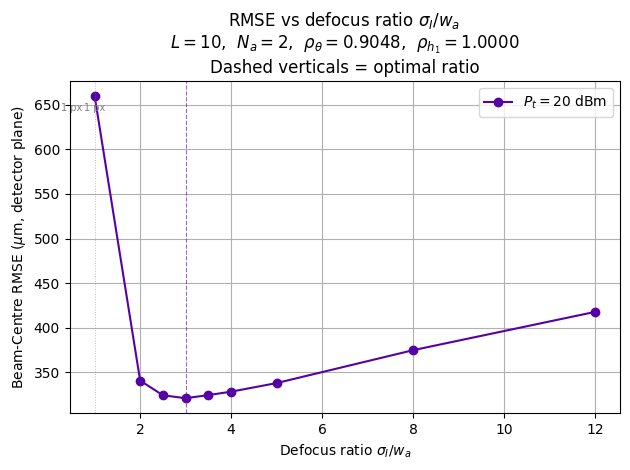


OPTIMAL sigma_I/wa SUMMARY
    Pt (dBm)   Optimal ratio   RMSE (um)
--------------------------------------------------
          20            3.00    320.9272


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math

def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))

def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa, sigma_I_ratio):
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)
    sigma_I = sigma_I_ratio * wa
    delta   = sigma_I * fc / ra
    fc_eff  = fc + delta
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I,
            "delta": delta, "fc_eff": fc_eff}

def ar1_coefficient(Tc, data_rate):
    return float(np.exp(-1.0 / (data_rate * Tc)))

def ar1_noise_std(sigma, rho):
    return sigma * np.sqrt(1.0 - rho**2)

def generate_ar1_block(B, L, sigma, rho, rng):
    sigma_w   = ar1_noise_std(sigma, rho)
    seq       = np.zeros((B, L))
    seq[:, 0] = rng.normal(0.0, sigma, size=B)
    for l in range(1, L):
        seq[:, l] = rho * seq[:, l-1] + sigma_w * rng.normal(0.0, 1.0, size=B)
    return seq

def malaga_pdf(h, alpha, beta, g, Omega):
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)
    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))
    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer.")
    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)
    return AM * out

def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    h_grid    = np.linspace(0.0, h_max, grid_n)
    h_grid[0] = 1e-12
    pdf       = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf       = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf      /= cdf[-1]
    return h_grid, cdf

def sample_malaga_batch(h_grid, cdf, size, rng):
    return np.interp(rng.random(size), cdf, h_grid)

def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    return np.exp(-zeta1 * Z) * sample_malaga_batch(h_grid, cdf, size, rng)

def generate_h1_ar1_block(B, L, Z, zeta1, h_grid, cdf, rho_h1, rng):
    hul      = np.exp(-zeta1 * Z)
    hua_0    = sample_malaga_batch(h_grid, cdf, size=B, rng=rng)
    log_hua  = np.log(np.maximum(hua_0, 1e-300))
    sigma_log = float(np.std(log_hua))
    if sigma_log < 1e-10:
        sigma_log = 1.0
    sigma_w_h1   = ar1_noise_std(sigma_log, rho_h1)
    h1_seq       = np.zeros((B, L))
    h1_seq[:, 0] = hul * hua_0
    for l in range(1, L):
        log_hua      = rho_h1 * log_hua + sigma_w_h1 * rng.normal(0.0, 1.0, size=B)
        h1_seq[:, l] = hul * np.exp(log_hua)
    return h1_seq

def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc_eff, sigma_I):
    w_prime  = wa + wf
    x0       = fc_eff * theta_x
    y0       = fc_eff * theta_y
    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1 = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2 = (x_right[None, :] - x0[:, None]) / sigma_I
    px  = Q(ax1) - Q(ax2)
    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1 = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2 = (y_top[None, :]    - y0[:, None]) / sigma_I
    py  = Q(ay1) - Q(ay2)
    h2  = px[:, :, None] * py[:, None, :]
    s   = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]
    return h2

def interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff):
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc_eff * theta_x)**2 + (fc_eff * theta_y)**2)
    return r_d > r_array

def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1
    gamma    = (mu * P_rx)**2 / (sigma_s**2 * P_rx + sigma0**2)
    return gamma < gamma_th

def generate_R_ar1_batch(Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
                          mu, sigma_s, sigma0, rng,
                          Z, zeta1, h_grid, cdf,
                          sigma_x, sigma_y,
                          rho_theta, rho_h1,
                          eta=1.0, p1=0.5):
    theta_x_seq = generate_ar1_block(B, L, sigma_x, rho_theta, rng)
    theta_y_seq = generate_ar1_block(B, L, sigma_y, rho_theta, rng)
    h1_seq      = generate_h1_ar1_block(B, L, Z, zeta1,
                                         h_grid, cdf, rho_h1, rng)
    R = np.zeros((B, Na, Na, L))
    for l in range(L):
        theta_x_l = theta_x_seq[:, l]
        theta_y_l = theta_y_seq[:, l]
        h1_l      = h1_seq[:, l]
        h2_l      = compute_h2_batch(theta_x_l, theta_y_l,
                                      Na, wa, wf, fc_eff, sigma_I)
        h_full_l  = h1_l[:, None, None] * h2_l
        s_l       = (rng.random(B) < p1).astype(float)
        s3        = s_l[:, None, None]
        Pt_rx     = eta * Pt
        mean_l    = mu * Pt_rx * h_full_l * s3
        var_l     = sigma_s**2 * (Pt_rx * h_full_l * s3) + sigma0**2
        R[:, :, :, l] = rng.normal(mean_l, np.sqrt(var_l))
    x_true    = fc_eff * theta_x_seq[:, L-1]
    y_true    = fc_eff * theta_y_seq[:, L-1]
    last_geom = interruption_mask(theta_x_seq[:, L-1],
                                   theta_y_seq[:, L-1],
                                   Na, wa, wf, fc_eff)
    last_snr  = snr_mask(h1_seq[:, L-1], Pt, mu, sigma_s, sigma0, eta)
    last_int  = last_geom | last_snr
    return R, x_true, y_true, last_int

def joint_track_h_hat_batch(R, mu):
    B, Na, _, L = R.shape
    y        = np.sum(R, axis=(1, 2))
    order    = np.argsort(-y, axis=1)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)
    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1
    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)
    s4           = s_hat_sorted[:, None, None, :]
    R_weighted   = R_sorted * s4
    h_hat        = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)
    return h_hat

def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    w_prime = wa + wf
    B       = h_hat.shape[0]
    x_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    h_pos   = np.maximum(h_hat, 0.0)
    total   = np.sum(h_pos, axis=(1, 2))
    hx      = np.sum(h_pos, axis=2)
    hy      = np.sum(h_pos, axis=1)
    safe    = total > 0
    x_hat   = np.zeros(B)
    y_hat   = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]
    return x_hat, y_hat

def rmse_for_params(Pt, params, h1_cdf, n_trials, rng,
                    batch_size=1000):
    """Compute RMSE and interruption fraction for given params and Pt."""
    Na        = params["Na"]
    wa        = params["wa"]
    wf        = params["wf"]
    fc_eff    = params["fc_eff"]
    sigma_I   = params["sigma_I"]
    L         = params["L"]
    mu        = params["mu"]
    sigma_s   = params["sigma_s"]
    sigma0    = params["sigma0"]
    eta       = params.get("eta", 1.0)
    Z         = params["Z"]
    zeta1     = params["zeta1"]
    sigma_x   = params["sigma_x"]
    sigma_y   = params["sigma_y"]
    rho_theta = params["rho_theta"]
    rho_h1    = params["rho_h1"]
    h_grid, cdf = h1_cdf
    sq_err_sum  = 0.0
    n_valid     = 0
    n_int       = 0
    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)
        R, x_true, y_true, last_int = generate_R_ar1_batch(
            Pt, B, L, Na, wa, wf, fc_eff, sigma_I,
            mu, sigma_s, sigma0, rng,
            Z, zeta1, h_grid, cdf,
            sigma_x, sigma_y, rho_theta, rho_h1, eta=eta)
        n_int += int(np.sum(last_int))
        keep = ~last_int
        if np.any(keep):
            h_hat        = joint_track_h_hat_batch(R[keep], mu)
            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)
            sq_err_sum  += np.sum((x_hat - x_true[keep])**2 +
                                   (y_hat - y_true[keep])**2)
            n_valid     += int(np.sum(keep))
        done += B
    rmse     = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac = n_int / n_trials
    return rmse, int_frac


# ======================
# Main: RMSE vs sigma_I/wa at fixed Pt — U-shaped curve
# ======================
if __name__ == "__main__":

    # --- Physical link parameters ---
    lam = 1550e-9
    Z   = 250
    Cn2 = 1.7e-13
    w0  = 0.03
    fc  = 0.05
    ra  = 0.05
    Na  = 2
    wa  = 2e-3

    # --- Malaga parameters ---
    rho_M       = 0.596
    Omega_prime = 1.3265
    b0          = 0.1079
    g           = 2 * b0 * (1 - rho_M)
    Omega       = Omega_prime
    alpha       = 2.296
    beta        = 2
    zeta1       = 0.43e-3

    # --- AR(1) parameters ---
    data_rate = 1e9
    Tc_theta  = 10e-9
    Tc_h1     = 2e-3
    rho_theta = ar1_coefficient(Tc_theta, data_rate)
    rho_h1    = ar1_coefficient(Tc_h1,    data_rate)

    print("=" * 55)
    print("AR(1) CORRELATION PARAMETERS")
    print("=" * 55)
    print(f"  data_rate   = {data_rate/1e9:.1f} Gbps")
    print(f"  t_slot      = {1/data_rate*1e9:.2f} ns")
    print(f"  Tc_theta    = {Tc_theta*1e3:.1f} ms  ->  rho_theta = {rho_theta:.6f}")
    print(f"  Tc_h1       = {Tc_h1*1e3:.1f} ms  ->  rho_h1    = {rho_h1:.6f}")
    print("=" * 55)
    print()

    # --- Build Malaga CDF once ---
    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.\n")

    # --- Fixed simulation settings ---
    L_fixed = 10

    # sigma_I/wa ratio sweep
    # Fine grid from 0.3 to Na/2 = 2.0 (beyond Na/2 spot leaks off array edges)
    # The U-shape arises because:
    #   Small ratio: spot concentrated in ~1 pixel -> centroid noisy (noise floor high)
    #   Large ratio: spot spread over many pixels -> centroid less sensitive to
    #                position shifts, and power leaks off array edges
    #   Optimal ratio: best tradeoff between sensitivity and noise
    sigma_ratio_list = [ 1.0, 2,2.5, 3.0,3.5,4, 5.0, 8.0,12.0]

    # Fixed transmit powers to evaluate — run one curve per power level
    # Choose powers spanning noise-limited to SNR-saturated regimes
    Pt_dBm_fixed_list = [ 20]

    QUICK = False
    if QUICK:
        n_trials   = 5_000
        batch_size = 500
    else:
        n_trials   = 50_000
        batch_size = 500

    rng = np.random.default_rng(1234)

    # --- Plot RMSE vs sigma_I/wa for each fixed Pt ---
    fig, ax = plt.subplots()
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(Pt_dBm_fixed_list)))

    opt_ratios = []

    for Pt_dBm, col in zip(Pt_dBm_fixed_list, colors):
        Pt = 10 ** ((Pt_dBm - 30) / 10.0)
        rmse_vals = []
        int_fracs = []

        print(f"\n--- Pt = {Pt_dBm} dBm ---")

        for ratio in sigma_ratio_list:
            link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa,
                                       sigma_I_ratio=ratio)
            params = {
                "Na"         : Na,
                "wa"         : wa,
                "wf"         : 0.0,
                "fc_eff"     : link["fc_eff"],
                "sigma_I"    : link["sigma_I"],
                "eta"        : link["eta"],
                "sigma_x"    : 4e-3,
                "sigma_y"    : 4e-3,
                "mu"         : 1.0,
                "sigma_s"    : 2e-5,
                "sigma0"     : 2e-6,
                "L"          : L_fixed,
                "Z"          : Z,
                "zeta1"      : zeta1,
                "gamma_th_dB": 5.0,
                "rho_theta"  : rho_theta,
                "rho_h1"     : rho_h1,
            }

            rmse, int_frac = rmse_for_params(
                Pt, params, (h_grid, cdf), n_trials, rng,
                batch_size=batch_size
            )
            rmse_vals.append(rmse * 1e6)
            int_fracs.append(int_frac)
            print(f"  sigma_I/wa={ratio:.2f}  "
                  f"sigma_I={link['sigma_I']*1e3:.2f}mm  "
                  f"fc_eff={link['fc_eff']*1e3:.2f}mm  "
                  f"RMSE={rmse*1e6:.4f} um  "
                  f"P_int={int_frac:.4f}")

        # Find and record optimal ratio
        valid = [r for r, v in zip(sigma_ratio_list, rmse_vals)
                 if not np.isnan(v)]
        valid_rmse = [v for v in rmse_vals if not np.isnan(v)]
        if valid_rmse:
            idx_opt   = int(np.argmin(valid_rmse))
            opt_ratio = valid[idx_opt]
            opt_rmse  = valid_rmse[idx_opt]
            opt_ratios.append((Pt_dBm, opt_ratio, opt_rmse))
            print(f"  -> Optimal sigma_I/wa = {opt_ratio:.2f}  "
                  f"(RMSE = {opt_rmse:.4f} um)")

        ax.plot(sigma_ratio_list, rmse_vals, marker="o", color=col,
                label=f"$P_t={Pt_dBm}$ dBm")

        # Mark optimal with vertical dashed line (same colour)
        if valid_rmse:
            ax.axvline(opt_ratio, color=col, linestyle="--",
                       linewidth=0.8, alpha=0.6)

    # Reference lines at pixel boundaries
    for k in range(1, Na):
        ax.axvline(k, color="gray", linestyle=":", linewidth=0.7, alpha=0.5)
    ax.text(0.5, ax.get_ylim()[1]*0.95, "1 px", ha="center",
            color="gray", fontsize=7)
    ax.text(1.0, ax.get_ylim()[1]*0.95, "1 px", ha="center",
            color="gray", fontsize=7)

    ax.set_xlabel(r"Defocus ratio $\sigma_I / w_a$")
    ax.set_ylabel(r"Beam-Centre RMSE ($\mu$m, detector plane)")
    ax.set_title(
        f"RMSE vs defocus ratio $\\sigma_I/w_a$ \n"
        f"$L={L_fixed}$,  $N_a={Na}$,  "
        f"$\\rho_\\theta={rho_theta:.4f}$,  "
        f"$\\rho_{{h_1}}={rho_h1:.4f}$\n"
        f"Dashed verticals = optimal ratio"
    )
    ax.grid(True, which="both")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    print("\n" + "=" * 50)
    print("OPTIMAL sigma_I/wa SUMMARY")
    print("=" * 50)
    print(f"  {'Pt (dBm)':>10}  {'Optimal ratio':>14}  {'RMSE (um)':>10}")
    print("-" * 50)
    for Pt_dBm, opt_r, opt_rmse in opt_ratios:
        print(f"  {Pt_dBm:>10}  {opt_r:>14.2f}  {opt_rmse:>10.4f}")
    print("=" * 50)